# Laboratorio: One-Class SVM RBF sobre métricas de software (KC1)

**Dataset:** [PROMISE / NASA KC1](https://www.openml.org/d/1067) — métricas estáticas de módulos de código (LOC, complejidad, acoplamiento, etc.). Cada fila es un **módulo**, no un instante temporal.

**Escenario AIOps / ingeniería de software:** el “normal” son módulos históricamente **sin defectos**; el OCSVM aprende esa región en **R{21}$** (21 features) y marca módulos **atípicos** para priorizar revisión o pruebas.

Flujo pedagógico:

1. explorar métricas tabulares y correlaciones,
2. entrenar solo con módulos sin defecto (`defects=false`),
3. puntuar todos los módulos y comparar con la etiqueta real,
4. visualizar frontera RBF en 2D (`loc` vs `branchCount`),
5. sensibilidad a `nu` y `gamma`.


## 0. Dependencias

Requiere conexión a internet la primera vez (`fetch_openml`).


In [1]:
# %pip install scikit-learn pandas matplotlib


## 1. Imports


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.datasets import fetch_openml
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
)
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
NU = 0.15  # ~fracción de módulos sin defecto que pueden quedar fuera (ver distribución real ~15% defectuosos)
rng = np.random.default_rng(RANDOM_STATE)
plt.style.use("default")

## 2. Cargar KC1 (métricas de software)

21 métricas por módulo (Halstead, complejidad ciclomática `v(g)`, LOC, acoplamiento, etc.) y variable objetivo `defects` (`true` / `false`).

Usamos la etiqueta **solo para evaluar**, no para entrenar el OCSVM.


In [3]:
kc1 = fetch_openml(data_id=1067, as_frame=True, parser="auto")
X_df = kc1.data.astype(float)
y = kc1.target.astype(str)

print("Módulos:", len(X_df), "| Features:", X_df.shape[1])
print(y.value_counts())
print()
X_df.describe().T.head(10)


Módulos: 2109 | Features: 21
defects
false    1783
true      326
Name: count, dtype: int64



,count,mean,std,min,25%,50%,75%,max
loc,2109.0,20.372262,29.754442,1.0,3.00,9.00,24.00,288.00
v(g),2109.0,2.838028,3.900763,1.0,1.00,1.00,3.00,45.00
ev(g),2109.0,1.674443,2.200659,1.0,1.00,1.00,1.00,26.00
iv(g),2109.0,2.546420,3.375859,1.0,1.00,1.00,3.00,45.00
n,2109.0,49.829445,83.599874,0.0,4.00,16.00,58.00,1106.00
v,2109.0,258.696719,516.317605,0.0,8.00,57.06,265.93,7918.82
l,2109.0,0.319583,0.317029,0.0,0.08,0.20,0.67,2.00
d,2109.0,6.771242,7.863646,0.0,1.50,3.50,9.20,53.75
i,2109.0,21.240071,21.500367,0.0,5.33,14.40,29.85,193.06
e,2109.0,5242.386240,17444.981211,0.0,12.00,213.97,2276.02,324803.51


### Diccionario de features (KC1 / OpenML)

Cada fila es un **módulo de código**; las columnas son métricas estáticas (McCabe, Halstead y LOC). Muchas están correlacionadas: un módulo grande suele tener LOC alto, más operadores y más ramas.

| Feature | Significado |
|---------|-------------|
| `loc` | Líneas de código del módulo |
| `v(g)` | Complejidad ciclomática (ramas / caminos en el flujo de control) |
| `ev(g)` | Complejidad ciclomática esencial |
| `iv(g)` | Complejidad de diseño del módulo |
| `branchCount` | Cantidad de ramas (if, while, switch, …) |
| `n` | Vocabulario Halstead (operadores únicos + operandos únicos) |
| `v` | Volumen Halstead |
| `l` | Longitud del programa (total operadores + operandos) |
| `d` | Dificultad Halstead |
| `i` | Contenido de inteligencia (esfuerzo mental estimado) |
| `e` | Esfuerzo de implementación estimado |
| `b` | Bugs estimados (heurística Halstead, no conteo real) |
| `t` | Tiempo estimado de programación (heurística) |
| `lOCode` | Líneas de código sin comentarios ni blancos |
| `lOComment` | Líneas de comentarios |
| `lOBlank` | Líneas en blanco |
| `locCodeAndComment` | LOC código + comentarios |
| `uniq_Op` | Operadores distintos |
| `uniq_Opnd` | Operandos distintos |
| `total_Op` | Total de operadores |
| `total_Opnd` | Total de operandos |

**Etiqueta** `defects`: `false` = sin defecto reportado; `true` = con defecto. En este laboratorio **no** entra al entrenamiento del OCSVM; solo sirve para evaluar si las anomalías coinciden con defectos históricos.

Referencia: [OpenML KC1 (id 1067)](https://www.openml.org/d/1067).


## 3. Vista tabular: correlación entre métricas

Patrones lineales fuertes (p. ej. LOC vs volumen) son normales en métricas de código. El OCSVM busca **combinaciones** que se salen del bulk de módulos sanos.


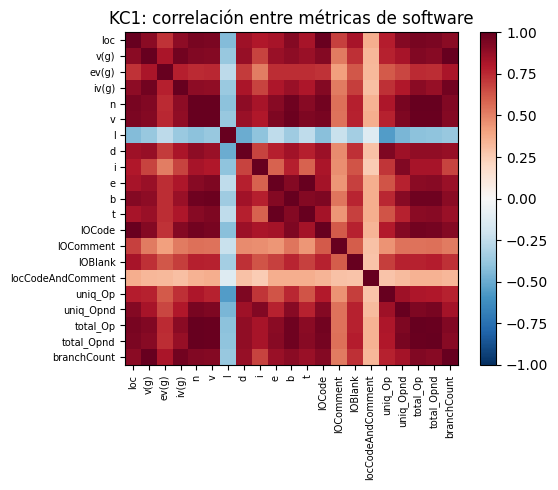

In [4]:
feature_cols = list(X_df.columns)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(X_df.corr(), cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(feature_cols)), feature_cols, rotation=90, fontsize=7)
ax.set_yticks(range(len(feature_cols)), feature_cols, fontsize=7)
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_title("KC1: correlación entre métricas de software")
plt.tight_layout()
plt.show()


## 4. Entrenamiento “solo normal” (one-class)

Convención: módulos con `defects=false` definen el comportamiento habitual del repositorio.

- Estandarizamos con media/desvío **solo de esos módulos**.
- `nu` controla qué fracción del train normal puede quedar fuera de la frontera (upper bound de sklearn).


In [5]:
normal_mask = y == "false"
defect_mask = y == "true"

X = X_df.to_numpy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X[normal_mask])
X_scaled_all = scaler.transform(X)

model = OneClassSVM(kernel="rbf", nu=NU, gamma="scale")
model.fit(X_scaled)

decision = model.decision_function(X_scaled_all)
pred = model.predict(X_scaled_all)

results = X_df.copy()
results["defects"] = y.values
results["decision_function"] = decision
results["anomaly_score"] = -decision
results["is_anomaly"] = pred == -1

print(f"Entrenados con {normal_mask.sum()} módulos sin defecto")
print(f"Marcados como anómalos (predict -1): {results['is_anomaly'].sum()} ({results['is_anomaly'].mean():.1%})")
print(f"Defectos reales en dataset: {defect_mask.sum()} ({defect_mask.mean():.1%})")


Entrenados con 1783 módulos sin defecto
Marcados como anómalos (predict -1): 428 (20.3%)
Defectos reales en dataset: 326 (15.5%)


## 5. ¿Detecta módulos con defectos? (evaluación)

No supervisado en entrenamiento, pero podemos medir **utilidad** contra la etiqueta histórica.


In [6]:
y_true = defect_mask.to_numpy()
y_pred = results["is_anomaly"].to_numpy()

print("Matriz de confusión (filas = defecto real, cols = OCSVM anómalo):")
print(confusion_matrix(y_true, y_pred, labels=[True, False]))
print()
print(classification_report(y_true, y_pred, target_names=["sin_defecto", "con_defecto"], zero_division=0))


Matriz de confusión (filas = defecto real, cols = OCSVM anómalo):
[[ 144  182]
 [ 284 1499]]

              precision    recall  f1-score   support

 sin_defecto       0.89      0.84      0.87      1783
 con_defecto       0.34      0.44      0.38       326

    accuracy                           0.78      2109
   macro avg       0.61      0.64      0.62      2109
weighted avg       0.81      0.78      0.79      2109



## 6. Ranking: top módulos anómalos

Revisar métricas concretas en los casos con mayor `anomaly_score`.


In [7]:
show_cols = [
    "defects", "anomaly_score", "decision_function",
    "loc", "v(g)", "ev(g)", "branchCount", "total_Opnd",
]
results.sort_values("anomaly_score", ascending=False).head(12)[show_cols]


,defects,anomaly_score,decision_function,loc,v(g),ev(g),branchCount,total_Opnd
286,true,53.323831,-53.323831,288.0,45.0,7.0,89.0,285.0
128,true,53.323831,-53.323831,286.0,27.0,5.0,53.0,171.0
299,true,53.323828,-53.323828,220.0,12.0,8.0,23.0,190.0
247,true,53.323820,-53.323820,145.0,25.0,21.0,49.0,173.0
309,true,53.315632,-53.315632,162.0,17.0,12.0,33.0,130.0
172,true,53.287441,-53.287441,184.0,16.0,12.0,31.0,180.0
237,true,53.276172,-53.276172,217.0,28.0,18.0,54.0,176.0
269,true,53.246674,-53.246674,176.0,16.0,10.0,31.0,156.0
315,true,53.208835,-53.208835,153.0,27.0,15.0,53.0,212.0
156,true,53.206595,-53.206595,62.0,14.0,1.0,36.0,163.0


## 7. Frontera RBF en 2D: `loc` vs `branchCount`

El modelo **real** usa 21 features; no se puede dibujar en un plano. Proyectamos a dos ejes y entrenamos un OCSVM **auxiliar 2D** solo para el **fondo**.

**Por qué este par:** entre pares interpretables, `loc` + `branchCount` tiene ~**90%** de acuerdo con el OCSVM 21D (igual que `loc` + `v(g)`) y AUC ligeramente mayor para defectos reales (~0.62). Alternativa con **más** separación visual: `d` + `i` (Halstead, AUC ~0.74), pero solo ~88% de acuerdo con el modelo de 21 features.

| Elemento | Significado |
|----------|-------------|
| Fondo | Frontera del OCSVM **2D auxiliar** |
| Punto **gris** | Modelo **real 21D**: normal |
| Punto **rojo** | Modelo **real 21D**: anomalía |
| **Borde negro** | Defecto histórico real (`defects=true`) |


/tmp/ipykernel_305382/3168004925.py:24: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(xx, yy, zz, levels=[0], colors="tab:red", linewidths=2, label="frontera OCSVM 2D (auxiliar)")


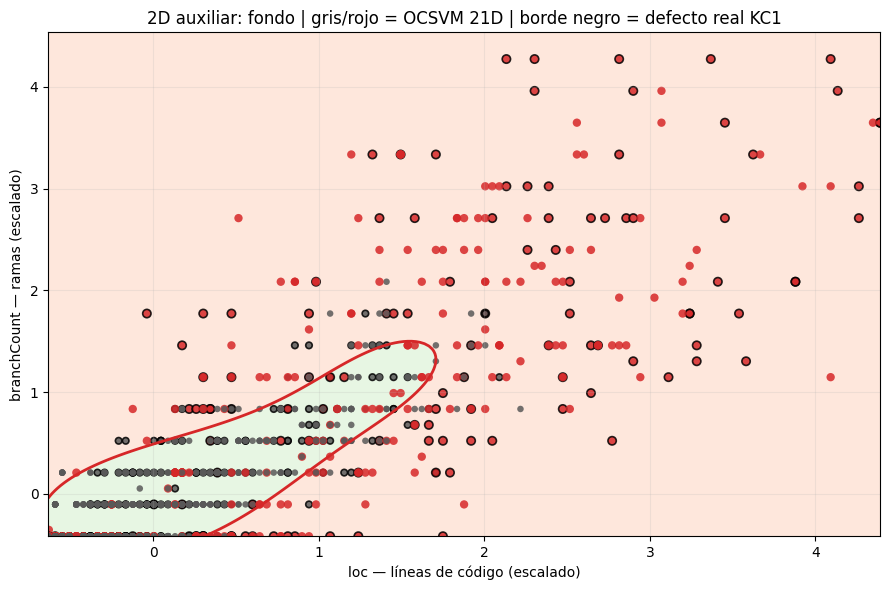

In [8]:
# Proyección 2D solo para DIBUJAR (el modelo real usa 21 features)
viz_cols = ["loc", "branchCount"]  # mejor acuerdo con OCSVM 21D que loc+v(g)
viz_idx = [feature_cols.index(c) for c in viz_cols]
X_viz = X_scaled_all[:, viz_idx]  # todos los módulos en el plano 2D elegido

# OCSVM auxiliar 2D: entrenado como el principal, solo con módulos sin defecto
viz_model = OneClassSVM(kernel="rbf", nu=NU, gamma="scale")
viz_model.fit(X_scaled[:, viz_idx])  # X_scaled = filas normales únicamente

x_lo, x_hi = np.percentile(X_viz[:, 0], [2, 98])
y_lo, y_hi = np.percentile(X_viz[:, 1], [2, 98])
xx, yy = np.meshgrid(np.linspace(x_lo, x_hi, 200), np.linspace(y_lo, y_hi, 200))
zz = viz_model.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# Color del punto = decisión del MODELO REAL (21D), no del auxiliar 2D
inside_main = results["decision_function"] >= 0
point_colors = np.where(inside_main, "0.35", "tab:red")
point_sizes = np.where(inside_main, 22, 36)
edge_colors = np.where(results["defects"] == "true", "black", "none")
edge_widths = np.where(results["defects"] == "true", 1.2, 0.0)

fig, ax = plt.subplots(figsize=(9, 6))
ax.contourf(xx, yy, zz, levels=[zz.min(), 0, zz.max()], colors=["#fee5d9", "#e5f5e0"], alpha=0.9)
ax.contour(xx, yy, zz, levels=[0], colors="tab:red", linewidths=2, label="frontera OCSVM 2D (auxiliar)")
ax.scatter(
    X_viz[:, 0], X_viz[:, 1], c=point_colors, s=point_sizes,
    edgecolors=edge_colors, linewidths=edge_widths, alpha=0.85,
)
ax.set_xlim(x_lo, x_hi)
ax.set_ylim(y_lo, y_hi)
ax.set_xlabel("loc — líneas de código (escalado)")
ax.set_ylabel("branchCount — ramas (escalado)")
ax.set_title("2D auxiliar: fondo | gris/rojo = OCSVM 21D | borde negro = defecto real KC1")
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


## 8. Barras: captura de defectos vs falsas alarmas


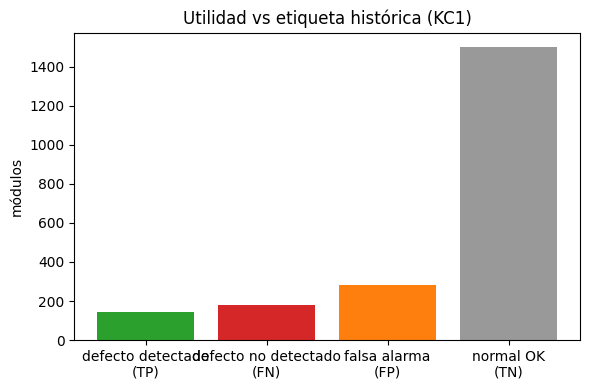

In [9]:
cm = confusion_matrix(y_true, y_pred)  # filas: sin defecto (0), con defecto (1)
tn, fp, fn, tp = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(
    ["defecto detectado\n(TP)", "defecto no detectado\n(FN)", "falsa alarma\n(FP)", "normal OK\n(TN)"],
    [tp, fn, fp, tn],
    color=["tab:green", "tab:red", "tab:orange", "0.6"],
)
ax.set_title("Utilidad vs etiqueta histórica (KC1)")
ax.set_ylabel("módulos")
plt.tight_layout()
plt.show()


## 9. Sensibilidad a `nu`


In [10]:
nu_grid = [0.05, 0.10, 0.15, 0.20, 0.25]
rows = []
for nu_c in nu_grid:
    m = OneClassSVM(kernel="rbf", nu=nu_c, gamma="scale")
    m.fit(X_scaled)
    pred_c = m.predict(X_scaled_all) == -1
    tp = ((pred_c) & defect_mask).sum()
    fp = ((pred_c) & normal_mask).sum()
    rows.append({"nu": nu_c, "anomalias": pred_c.sum(), "TP_defectos": int(tp), "FP_normales": int(fp)})
pd.DataFrame(rows)


,nu,anomalias,TP_defectos,FP_normales
0,0.05,178,90,88
1,0.10,292,122,170
2,0.15,428,144,284
3,0.20,518,165,353
4,0.25,620,179,441


## 10. Sensibilidad a `gamma`


In [11]:
gamma_grid = ["scale", 0.05, 0.2, 1.0]
grow = []
for g in gamma_grid:
    m = OneClassSVM(kernel="rbf", nu=NU, gamma=g)
    m.fit(X_scaled)
    pred_g = m.predict(X_scaled_all) == -1
    tp = ((pred_g) & defect_mask).sum()
    grow.append({"gamma": g, "anomalias": int(pred_g.sum()), "TP_defectos": int(tp)})
pd.DataFrame(grow)


,gamma,anomalias,TP_defectos
0,scale,428,144
1,0.05,404,143
2,0.2,450,161
3,1.0,602,220


## 11. Puente con AIOps (discusión)

| Serie temporal (KPI/minuto) | Métricas de software (KC1) |
|-----------------------------|----------------------------|
| Fila = instante | Fila = módulo / servicio / build |
| Deriva, estacionalidad | Cambio de código, deuda técnica |
| Features de ventana | Métricas de SonarQube, coverage, complejidad |

El **mismo algoritmo** (OCSVM + RBF + escalado) aplica a ambos; cambia el **dominio** y el diseño del train set (aquí: solo "sin defecto").

> La sección 12 resuelve los ejercicios del obligatorio sobre este mismo dataset.

## 12. Ejercicios para obligatorio

- **12.1** — Tabla amplia de `nu` con precision / recall / F1 (clase *defecto*) y ROC-AUC → elegir el mejor `nu`.
- **12.2** — Grid `nu × gamma` para *tunear* la SVM y quedarnos con la mejor combinación.
- **12.3** — Isolation Forest sobre las **21 columnas** y **tabla comparativa final** IF vs OCSVM, con la conclusión.

In [12]:
# 12.1 "Buena tablita de nu": barrido amplio con métricas completas (clase positiva = defecto)
y_defect = defect_mask.to_numpy()


def eval_anomaly_flags(flags, scores, y_defect):
    """Métricas tratando 'anomalía marcada' como predicción de 'defecto'."""
    flags = np.asarray(flags)
    y_defect = np.asarray(y_defect)
    tp = int((flags & y_defect).sum())
    fp = int((flags & ~y_defect).sum())
    fn = int((~flags & y_defect).sum())
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return {
        "anomalias": int(flags.sum()),
        "TP": tp, "FP": fp, "FN": fn,
        "precision": round(precision, 3),
        "recall": round(recall, 3),
        "F1": round(f1, 3),
        "ROC_AUC": round(roc_auc_score(y_defect, scores), 3),
    }


nu_grid_full = [0.02, 0.05, 0.08, 0.10, 0.12, 0.15, 0.20, 0.25, 0.30]
nu_rows = []
for nu_c in nu_grid_full:
    m = OneClassSVM(kernel="rbf", nu=nu_c, gamma="scale").fit(X_scaled)
    flags = m.predict(X_scaled_all) == -1
    scores = -m.decision_function(X_scaled_all)
    nu_rows.append({"nu": nu_c, **eval_anomaly_flags(flags, scores, y_defect)})

nu_tbl = pd.DataFrame(nu_rows)
best_nu = nu_tbl.loc[nu_tbl["F1"].idxmax(), "nu"]
print(f"Mejor nu por F1 (clase defecto): {best_nu}")
print("Nota: ROC_AUC varía poco con nu (nu mueve sobre todo el umbral, no el orden de scores).")
nu_tbl

Mejor nu por F1 (clase defecto): 0.12
Nota: ROC_AUC varía poco con nu (nu mueve sobre todo el umbral, no el orden de scores).


,nu,anomalias,TP,FP,FN,precision,recall,F1,ROC_AUC
0,0.02,130,79,51,247,0.608,0.242,0.346,0.611
1,0.05,178,90,88,236,0.506,0.276,0.357,0.608
2,0.08,252,114,138,212,0.452,0.350,0.394,0.594
3,0.10,292,122,170,204,0.418,0.374,0.395,0.611
4,0.12,341,132,209,194,0.387,0.405,0.396,0.575
5,0.15,428,144,284,182,0.336,0.442,0.382,0.609
6,0.20,518,165,353,161,0.319,0.506,0.391,0.650
7,0.25,620,179,441,147,0.289,0.549,0.378,0.676
8,0.30,719,205,514,121,0.285,0.629,0.392,0.682


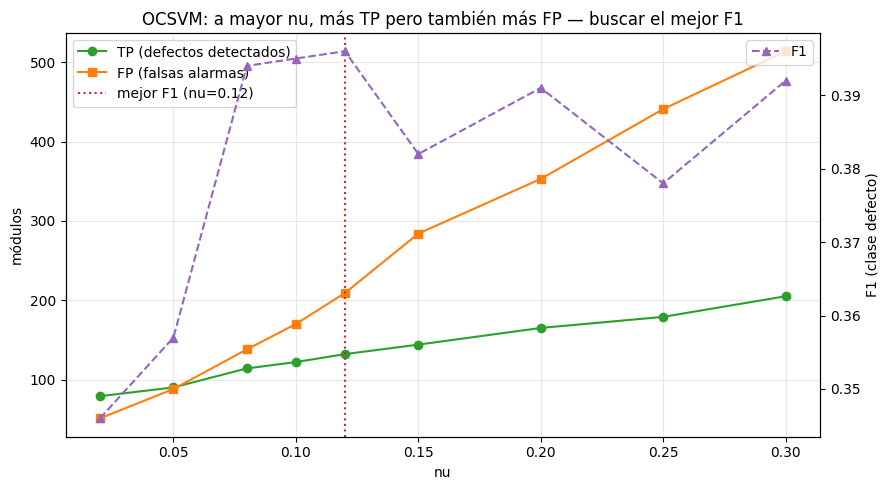

In [13]:
# Visualizar el trade-off: TP / FP / F1 a lo largo del barrido de nu
fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(nu_tbl["nu"], nu_tbl["TP"], "o-", color="tab:green", label="TP (defectos detectados)")
ax1.plot(nu_tbl["nu"], nu_tbl["FP"], "s-", color="tab:orange", label="FP (falsas alarmas)")
ax1.set_xlabel("nu"); ax1.set_ylabel("módulos")
ax1.axvline(best_nu, color="tab:red", linestyle=":", linewidth=1.5, label=f"mejor F1 (nu={best_nu})")
ax1.legend(loc="upper left"); ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(nu_tbl["nu"], nu_tbl["F1"], "^--", color="tab:purple", label="F1")
ax2.set_ylabel("F1 (clase defecto)")
ax2.legend(loc="upper right")

ax1.set_title("OCSVM: a mayor nu, más TP pero también más FP — buscar el mejor F1")
plt.tight_layout()
plt.show()

In [14]:
# 12.2 Tunear hiperparámetros: grid nu x gamma (F1 de la clase defecto)
gamma_grid = ["scale", 0.01, 0.05, 0.1, 0.2]
nu_focus = [0.05, 0.10, 0.15, 0.20, 0.25]

grid_rows = []
for g in gamma_grid:
    for nu_c in nu_focus:
        m = OneClassSVM(kernel="rbf", nu=nu_c, gamma=g).fit(X_scaled)
        flags = m.predict(X_scaled_all) == -1
        scores = -m.decision_function(X_scaled_all)
        ev = eval_anomaly_flags(flags, scores, y_defect)
        grid_rows.append({"gamma": g, "nu": nu_c, "F1": ev["F1"],
                          "ROC_AUC": ev["ROC_AUC"], "TP": ev["TP"], "FP": ev["FP"]})

grid_tbl = pd.DataFrame(grid_rows)
best_combo = grid_tbl.loc[grid_tbl["F1"].idxmax()]
best_ocsvm_nu = best_combo["nu"]
best_ocsvm_gamma = best_combo["gamma"]
print(f"Mejor combinación OCSVM por F1: nu={best_ocsvm_nu}, gamma={best_ocsvm_gamma} "
      f"(F1={best_combo['F1']}, AUC={best_combo['ROC_AUC']})\n")
print("F1 por (gamma, nu):")
grid_tbl.pivot(index="gamma", columns="nu", values="F1")

Mejor combinación OCSVM por F1: nu=0.05, gamma=0.2 (F1=0.472, AUC=0.64)

F1 por (gamma, nu):


nu,0.05,0.10,0.15,0.20,0.25
gamma,,,,,
0.01,0.290,0.358,0.337,0.335,0.362
0.05,0.358,0.390,0.392,0.390,0.383
0.1,0.401,0.411,0.428,0.411,0.401
0.2,0.472,0.426,0.415,0.419,0.412
scale,0.357,0.395,0.382,0.391,0.378


### 12.3 Isolation Forest sobre las 21 columnas + comparación

Entrenar un **Isolation Forest** con las **mismas 21 features** y comparar contra el mejor OCSVM. Diferencias clave de diseño:

- **OCSVM**: entrena *solo con módulos sin defecto* (one-class puro), escala con la media/desvío de esos módulos.
- **Isolation Forest**: entrena con *todos* los módulos, `contamination` ≈ tasa real de defectos. Es casi insensible a la escala.

Evaluamos ambos con las mismas métricas (precision/recall/F1 de la clase *defecto*) y, sobre todo, con **ROC-AUC** sobre el `anomaly_score`, que es **independiente del umbral** y mide qué tan bien cada modelo *ordena* los defectos.

In [15]:
# Ej. 2 -- Isolation Forest sobre las MISMAS 21 columnas, evaluado con las mismas métricas
defect_rate = float(defect_mask.mean())

# IF es casi insensible a la escala (cortes axis-aligned); estandarizamos igual para comparar limpio.
scaler_all = StandardScaler()
X_if = scaler_all.fit_transform(X)  # X = X_df.to_numpy(), las 21 features

if_model = IsolationForest(
    n_estimators=300,
    contamination=defect_rate,   # marcamos ~la tasa real de defectos
    random_state=RANDOM_STATE,
)
if_flags = if_model.fit_predict(X_if) == -1
if_scores = -if_model.score_samples(X_if)

if_eval = eval_anomaly_flags(if_flags, if_scores, y_defect)
print(f"Isolation Forest sobre 21 columnas (contamination={defect_rate:.3f}):")
pd.DataFrame([if_eval])

Isolation Forest sobre 21 columnas (contamination=0.155):


,anomalias,TP,FP,FN,precision,recall,F1,ROC_AUC
0,326,133,193,193,0.408,0.408,0.408,0.79


In [16]:
# Tabla comparativa final: mejor OCSVM tuneado vs Isolation Forest (21 columnas)
best_svm = OneClassSVM(kernel="rbf", nu=float(best_ocsvm_nu), gamma=best_ocsvm_gamma).fit(X_scaled)
svm_flags = best_svm.predict(X_scaled_all) == -1
svm_scores = -best_svm.decision_function(X_scaled_all)
svm_eval = eval_anomaly_flags(svm_flags, svm_scores, y_defect)

comparison = pd.DataFrame([
    {"modelo": f"OCSVM RBF tuneado (nu={best_ocsvm_nu}, gamma={best_ocsvm_gamma})", **svm_eval},
    {"modelo": f"IsolationForest 21 cols (cont={defect_rate:.3f})", **if_eval},
])
print("Comparación final (clase positiva = defecto):")
comparison

Comparación final (clase positiva = defecto):


,modelo,anomalias,TP,FP,FN,precision,recall,F1,ROC_AUC
0,"OCSVM RBF tuneado (nu=0.05, gamma=0.2)",271,141,130,185,0.520,0.433,0.472,0.64
1,IsolationForest 21 cols (cont=0.155),326,133,193,193,0.408,0.408,0.408,0.79


### Reporte: ¿da mejor Isolation Forest o una SVM tuneada?

**Cómo comparamos.** Ambos modelos son **no supervisados**; la etiqueta `defects` solo se usa para *evaluar*. Miramos dos planos:

- **Métricas dependientes del umbral** (precision/recall/F1 de la clase *defecto*): dependen de `nu` (OCSVM) o `contamination` (IF), que fijan *cuántos* módulos se marcan.
- **ROC-AUC sobre el `anomaly_score`**: **independiente del umbral**; mide qué tan bien cada modelo *ordena* los defectos por encima de los módulos sanos. Es la comparación más limpia de "qué separa mejor el problema".

**Resultados obtenidos (tabla comparativa anterior).**

| Modelo | precision | recall | F1 | ROC-AUC |
|--------|-----------|--------|----|---------|
| OCSVM RBF tuneado (`nu=0.05`, `gamma=0.2`) | **0.520** | 0.433 | **0.472** | 0.64 |
| Isolation Forest (21 cols, `cont=0.155`) | 0.408 | 0.408 | 0.408 | **0.79** |

El resultado está **dividido y hay que leerlo con cuidado**:

- En su **punto de operación**, la SVM tuneada gana en F1 (0.47 vs 0.41) y precision (0.52 vs 0.41): marca menos módulos (271 vs 326) pero con más aciertos. Eso sí, requirió **buscar `nu` y `gamma`** en una tablita + grid; con `gamma="scale"` por defecto rinde bastante peor (F1 ~0.38).
- En **ROC-AUC** —la métrica independiente del umbral— el **Isolation Forest gana con claridad (0.79 vs 0.64)**: ordena mucho mejor los módulos defectuosos. Su F1 más bajo es un artefacto del umbral elegido (`contamination`=tasa de defectos, que lo obliga a marcar exactamente 326); moviendo ese umbral, su mayor poder de ranking puede superar a la SVM.

**Conclusión para este dataset (KC1).** KC1 está muy desbalanceado (~15% defectos) y con features fuertemente correlacionadas (LOC ↔ volumen ↔ operadores): el defecto **no** es un outlier geométrico claro, muchos módulos defectuosos viven *dentro* de la nube de sanos, y por eso **ningún detector no supervisado logra F1 alto** (ambos ≈0.4–0.47). Dicho eso, **para este problema el Isolation Forest es la mejor opción**: separa mejor en términos de ranking (AUC 0.79) y es **mucho más robusto de operar** (pocos hiperparámetros, insensible a escala, entrena sobre todos los datos). La SVM solo lo iguala/supera en F1 en un **punto de operación afinado a mano** y a costa de tunear `nu`+`gamma`.

> Recomendación práctica: **Isolation Forest** como detector por defecto (mejor AUC, poco tuning); el **OCSVM** queda como alternativa cuando existe un conjunto "normal" confiable y se puede invertir en tunear `nu`/`gamma` para exprimir precision en un punto concreto. La etiqueta histórica sirve para *calibrar* el umbral, no para entrenar.